# YZ50 — Week 2: Backpropagation

# 1. Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın

- Value class

In [21]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # bu node'un gradyanı 
        self._prev = set(_children) # bu node'u oluştururken kullanılan önceki Value objelerini saklar.
        self._op = _op # hangi işlemle bu node'un oluşturulduğunu saklar.
        self.label = label

    def __repr__(self):
        return f"Data({self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
# a + b  # = a.__add__(b)
# a * b  # = a.__mul__(b)
e = a*b; e.label = 'e'
# d = a*b + c # = (a.__mul__(b)).__add__(c) # '+'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Data(-8.0)

In [22]:
d._prev

{Data(-6.0), Data(10.0)}

In [23]:
d._op

'+'

##  Graph Virtualization

In [24]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

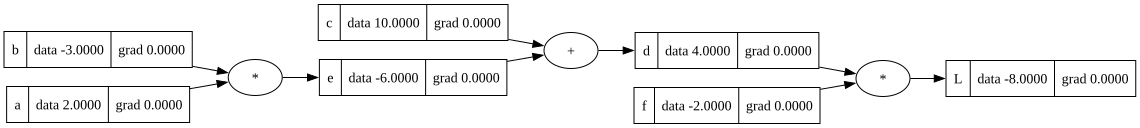

In [25]:
draw_dot(L)